In [2]:
# =================================================================
# LIBRERÍAS PARA EL PROYECTO DE DIAGNÓSTICO VIAL - NAVOJOA
# =================================================================

# Gestión de sistema y archivos
import os
import random
import shutil
from tqdm import tqdm

# Procesamiento geoespacial y vectorial
import rasterio
from rasterio import features
from rasterio.windows import Window
import geopandas as gpd
from shapely.geometry import shape

# Cálculo numérico y análisis de datos
import numpy as np
import pandas as pd

# Deep Learning y Visión Artificial
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

# Métricas y Visualización
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import classification_report, jaccard_score

c:\Users\celso\OneDrive\Documentos\Diplomado de Ciencia de Datos\Navojoa_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

# 1. Carga de archivo Geopackage
gdf = gpd.read_file('data_navojoa.gpkg')

# 2. Se cuentan valores nulos
nulos_antes = gdf['clase'].isna().sum()
total_filas = len(gdf)

print("--- REVISIÓN DE DATOS ---")
print(f"Total de registros: {total_filas}")
print(f"Registros con NaN (nulos): {nulos_antes}")
print(f"Valores únicos actuales: {gdf['clase'].unique()}")

# 3. Se limpian valores nulos
# Convertimos NaN a 0 y aseguramos que sea entero
gdf['clase'] = gdf['clase'].fillna(0).astype(int)

# 4. Verificación
print("\n--- RESULTADO TRAS LIMPIEZA ---")
conteo_clases = gdf['clase'].value_counts().sort_index()
for clase, cantidad in conteo_clases.items():
    nombre = {0: "Fondo/Nulo", 1: "Pavimento", 2: "Tierra", 3: "Dañada"}.get(clase, f"Clase {clase}")
    print(f"-> {nombre}: {cantidad} registros")

# 5. Se guarda si no hay nulos
if nulos_antes > 0:
    gdf.to_file('data_navojoa_limpio.gpkg', driver="GPKG")
    print("\n Archivo 'data_navojoa_limpio.gpkg' generado con éxito.")
else:
    print("\n No se detectaron nulos, puedes usar tu archivo original.")


--- REVISIÓN DE DATOS ---
Total de registros: 312
Registros con NaN (nulos): 1
Valores únicos actuales: [ 3.  1.  2. nan]

--- RESULTADO TRAS LIMPIEZA ---
-> Fondo/Nulo: 1 registros
-> Pavimento: 104 registros
-> Tierra: 71 registros
-> Dañada: 136 registros

✅ Archivo 'data_navojoa_limpio.gpkg' generado con éxito.


In [5]:

# CONFIGURACIÓN DE ARCHIVOS
RUTA_TIF_ORIGINAL = 'navojoa_data.tif'
RUTA_GPKG_CALLES = 'data_navojoa_limpio.gpkg'
COLUMNA_CLASE_GPKG = "clase"

# CONFIGURACIÓN DE SALIDA
OUTPUT_BASE_DIR = 'dataset_navojoa_final'
TILE_SIZE = 256
RASTER_MASCARA_TEMPORAL = 'temp_mask_aligned.tif'
SPLIT_TRAIN = 0.70    
SPLIT_VAL = 0.15      
random.seed(42)

print("Configuración cargada con éxito.")

Configuración cargada con éxito.


In [ ]:
#En este bloque, se están sobreponiendo la imagen en formato TIFF con el formato GEOPACKAGE
#SE CREA UN ARCHIVO TEMPORAL
# 1. Cargar y proyectar vectores
gdf = gpd.read_file(RUTA_GPKG_CALLES)

with rasterio.open(RUTA_TIF_ORIGINAL) as src:
    # Alinear coordenadas del vector con la imagen
    gdf = gdf.to_crs(src.crs)
    
    # 2. Configurar el archivo de salida
    # Utilicé 'tiled=True' y 'uint8' para que Windows no se rompa
    meta = src.meta.copy()
    meta.update(
        dtype='uint8', 
        count=1, 
        nodata=0, 
        compress='lzw',
        tiled=True,
        blockxsize=256,
        blockysize=256
    )

    with rasterio.open(RASTER_MASCARA_TEMPORAL, 'w', **meta) as out:
        
        shapes = ((geom, int(val)) for geom, val in zip(gdf.geometry, gdf[COLUMNA_CLASE_GPKG]))
        
        burned = features.rasterize(
            shapes=shapes,
            out_shape=(src.height, src.width),
            transform=out.transform,
            fill=0,
            all_touched=True,
            dtype='uint8'
        )
        out.write(burned, 1)


--- 1. Generando Máscara Gigante (Usando espacio en Disco) ---
Pintando calles... esto usará tu espacio en disco, no tu RAM.
✅ ¡Éxito! Máscara creada. Ahora el archivo reside en tus 49GB disponibles.


In [ ]:
##PREPARANDO LAS CARPETAS PARA ENTRENAMIENTO, VALIDACIÓN Y PRUEBA FINAL
def preparar_carpetas(base_dir):
    if os.path.exists(base_dir):
        shutil.rmtree(base_dir)
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(base_dir, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(base_dir, split, 'masks'), exist_ok=True)

preparar_carpetas(OUTPUT_BASE_DIR)
print(f"Estructura de carpetas creada en: {OUTPUT_BASE_DIR}")

Estructura de carpetas creada en: dataset_navojoa_final


In [ ]:
#LE ARCHIVO QUE RESULTO DE SOBREPPONER EL TIFF Y EL GEOPACKAGE SE DIVIDE EN RECORTES, 
#OJO SOLO GUARDAN DONDE COINCIDEN AMOBOS YA QUE ES SOLO UNA MUESTRA DEL MAPA
#SE ELIMINÓ EL ARCHIVO TEMPORAL
with rasterio.open(RUTA_TIF_ORIGINAL) as src_img, \
     rasterio.open(RASTER_MASCARA_TEMPORAL) as src_mask:
    
    width, height = src_img.width, src_img.height
    count_saved = 0

    for j in tqdm(range(0, height, TILE_SIZE), desc="Filas"):
        for i in range(0, width, TILE_SIZE):
            window = Window(i, j, TILE_SIZE, TILE_SIZE)
            
            # Leer fragmentos
            img_data = src_img.read([1, 2, 3], window=window)
            mask_data = src_mask.read(1, window=window)

            # Validar tamaño (ignorar bordes incompletos)
            if img_data.shape[1] < TILE_SIZE or img_data.shape[2] < TILE_SIZE:
                continue
                
            # Validar contenido (solo guardar si hay calles)
            if np.max(mask_data) == 0:
                continue

            # Decidir carpeta (Split)
            r = random.random()
            if r < SPLIT_TRAIN:
                split = 'train'
            elif r < (SPLIT_TRAIN + SPLIT_VAL):
                split = 'val'
            else:
                split = 'test'

            nombre = f"navojoa_{i}_{j}.tif"
            
            # GUARDAR IMAGEN
            meta_img = src_img.profile.copy()
            meta_img.update({'width': TILE_SIZE, 'height': TILE_SIZE, 'count': 3, 
                             'transform': src_img.window_transform(window)})
            with rasterio.open(os.path.join(OUTPUT_BASE_DIR, split, 'images', nombre), 'w', **meta_img) as dst:
                dst.write(img_data)

            # GUARDAR MÁSCARA
            meta_mask = src_mask.profile.copy()
            meta_mask.update({'width': TILE_SIZE, 'height': TILE_SIZE, 'count': 1, 'dtype': 'uint8', 
                              'transform': src_mask.window_transform(window)})
            with rasterio.open(os.path.join(OUTPUT_BASE_DIR, split, 'masks', nombre), 'w', **meta_mask) as dst:
                dst.write(mask_data.astype(np.uint8), indexes=1) # indexes=1 para evitar error
            
            count_saved += 1

# Limpiar archivo temporal
if os.path.exists(RASTER_MASCARA_TEMPORAL):
    os.remove(RASTER_MASCARA_TEMPORAL)

print(f"\nProceso finalizado. Total de imágenes generadas: {count_saved}")


--- 2. Iniciando proceso de recortes ---


Filas:   0%|          | 0/129 [00:00<?, ?it/s]

Filas: 100%|██████████| 129/129 [00:36<00:00,  3.56it/s]



Proceso finalizado. Total de imágenes generadas: 956


In [7]:



class NavojoaDataset(Dataset):
    
    def __init__(self, root_dir, split='train', transform=None):
        # SE BUSCAN LAS CARPETAS DONDE ESTAN LAS FOTOS Y LAS MASCARAS
        self.img_dir = os.path.join(root_dir, split, 'images')
        self.mask_dir = os.path.join(root_dir, split, 'masks')
        
        # SE GENERÓ UNA LISTA CON LOS NOMBRES DE TODAS LAS FOTOS QUE ENCONTRAMOS
        self.images = os.listdir(self.img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        # B) nORMALIZACION DE DATOS (ENTRE 0 Y 1)
        with rasterio.open(img_path) as src:
            
            image = src.read([1, 2, 3]).astype(np.float32) / 255.0
        
        # SE ABRE LA MASCARA (EL ETIQUETADO QUE HICIMOS EN QGIS)
        with rasterio.open(mask_path) as src:
            # LOS NUMEROS DE LAS CLASES: 0, 1, 2 Y 3
            mask = src.read(1).astype(np.longlong)

        # SE CONVIERTE A TENSORES
        return torch.from_numpy(image), torch.from_numpy(mask)

In [8]:
# Modelo U-Net con un ResNet34
# classes=4 (0:Fondo, 1:Pavimento, 2:Tierra, 3:Dañada)
model = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=4,                      
)

#Función de Pérdida (Dice Loss para múltiples clases)
criterion = smp.losses.DiceLoss(mode='multiclass')

#Optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


In [ ]:
#ENTRENAMIENTO DE 24 EPOCAS

#Configuración de Datasets
train_dataset = NavojoaDataset('dataset_navojoa_final', split='train')
val_dataset = NavojoaDataset('dataset_navojoa_final', split='val')

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Entrenando en: {device}")

# --- FUNCIÓN DE ENTRENAMIENTO ---
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

# --- FUNCIÓN DE VALIDACIÓN ---
def validate(model, loader, criterion):
    model.eval() # Modo evaluación: apaga Dropout y Batchnorm
    total_loss = 0
    with torch.no_grad(): # No calcula gradientes, ahorra memoria RAM/CPU
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
    return total_loss / len(loader)

# --- CICLO DE ENTRENAMIENTO PRINCIPAL ---
best_val_loss = float('inf') # Para guardar solo el mejor modelo

for epoch in range(24):
    # Paso 1: Entrenar
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    
    # Paso 2: Validar (Usando datos que el modelo no ha visto para aprender)
    val_loss = validate(model, val_loader, criterion)
    
    print(f"Época {epoch+1:02d} - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Paso 3: Guardar el modelo solo si es el "mejor" hasta ahora
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "modelo_calles_navojoa_best.pth")
        print(f"Modelo guardado con Val Loss: {val_loss:.4f}")

print("\nEntrenamiento finalizado.")


Entrenando en: cpu
Época 01 - Train Loss: 0.7076 | Val Loss: 0.5365
⭐ ¡Nuevo récord! Modelo guardado con Val Loss: 0.5365
Época 02 - Train Loss: 0.5833 | Val Loss: 0.4412
⭐ ¡Nuevo récord! Modelo guardado con Val Loss: 0.4412
Época 03 - Train Loss: 0.4390 | Val Loss: 0.3911
⭐ ¡Nuevo récord! Modelo guardado con Val Loss: 0.3911
Época 04 - Train Loss: 0.3835 | Val Loss: 0.3565
⭐ ¡Nuevo récord! Modelo guardado con Val Loss: 0.3565
Época 05 - Train Loss: 0.3304 | Val Loss: 0.3317
⭐ ¡Nuevo récord! Modelo guardado con Val Loss: 0.3317
Época 06 - Train Loss: 0.2960 | Val Loss: 0.3607
Época 07 - Train Loss: 0.2857 | Val Loss: 0.3219
⭐ ¡Nuevo récord! Modelo guardado con Val Loss: 0.3219
Época 08 - Train Loss: 0.2465 | Val Loss: 0.3463
Época 09 - Train Loss: 0.2158 | Val Loss: 0.3355
Época 10 - Train Loss: 0.2039 | Val Loss: 0.3084
⭐ ¡Nuevo récord! Modelo guardado con Val Loss: 0.3084
Época 11 - Train Loss: 0.1690 | Val Loss: 0.3068
⭐ ¡Nuevo récord! Modelo guardado con Val Loss: 0.3068
Época 12 -

In [9]:
#UNA VEZ ENTRENADO EL MODELO SE PROCEDE A REALIZAR UNA PRUEBA FINAL CON IMÁGENES que no ha visto

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_dataset = NavojoaDataset('dataset_navojoa_final', split='test')
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

#Carga Del Modelo

checkpoint_path = "modelo_calles_navojoa_best.pth" 

print(f"Cargando pesos desde: {checkpoint_path}")
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device)
model.eval()

# Evaluación
all_preds = []
all_masks = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.append(preds.flatten())
        all_masks.append(masks.numpy().flatten())

all_preds = np.concatenate(all_preds)
all_masks = np.concatenate(all_masks)

# rESUMEN
clases = ["Fondo", "Pavimento", "Tierra", "Dañada"]
print("\n" + "="*40)
print("       RESULTADOS FINALES (TEST)")
print("="*40)
print(classification_report(all_masks, all_preds, target_names=clases[:len(np.unique(all_masks))]))

Cargando pesos desde: modelo_calles_navojoa_best.pth

       RESULTADOS FINALES (TEST)
              precision    recall  f1-score   support

       Fondo       0.94      0.95      0.94   8256705
   Pavimento       0.75      0.74      0.75   1093215
      Tierra       0.59      0.55      0.57    260906
      Dañada       0.46      0.40      0.43    416182

    accuracy                           0.89  10027008
   macro avg       0.68      0.66      0.67  10027008
weighted avg       0.89      0.89      0.89  10027008



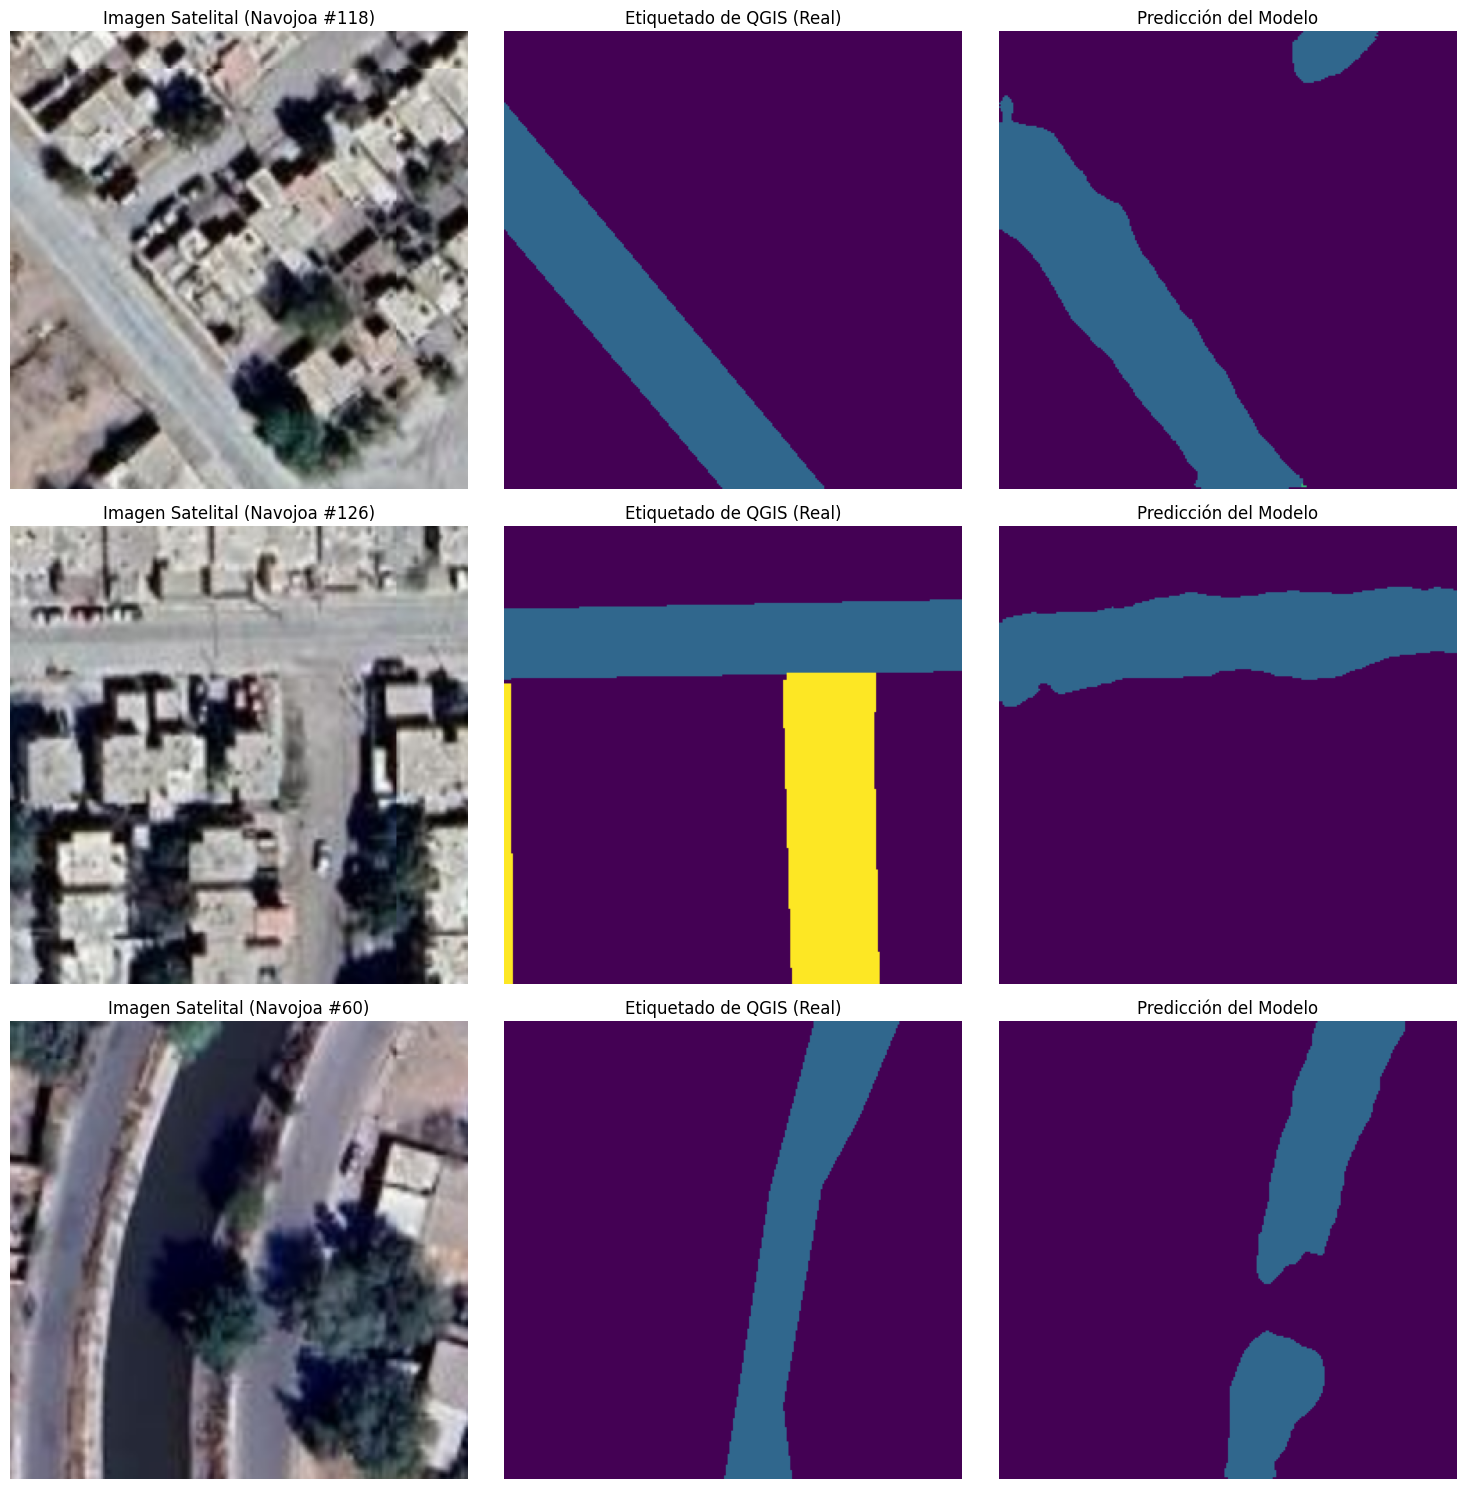

In [10]:
#GRÁFICO DE IMÁGENES ALEATORIAS
import matplotlib.pyplot as plt

def plot_test_results(model, dataset, num_images=3):
    model.eval()
    fig, axes = plt.subplots(num_images, 3, figsize=(15, num_images * 5))
    
    clases_colores = {0: 'black', 1: 'blue', 2: 'brown', 3: 'red'} # Fondo, Pav, Tierra, Dañada
    
    for i in range(num_images):
        # Elegir una imagen aleatoria del set de TEST
        idx = np.random.randint(0, len(dataset))
        image, mask = dataset[idx]
        
        # Predicción
        input_img = image.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_img)
            pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        
        # Visualización
        axes[i, 0].imshow(image.permute(1, 2, 0).numpy())
        axes[i, 0].set_title(f"Imagen Satelital (Navojoa #{idx})")
        
        axes[i, 1].imshow(mask.numpy(), vmin=0, vmax=3)
        axes[i, 1].set_title("Etiquetado de QGIS (Real)")
        
        axes[i, 2].imshow(pred, vmin=0, vmax=3)
        axes[i, 2].set_title("Predicción del Modelo")
        
        for ax in axes[i]: ax.axis('off')

    plt.tight_layout()
    plt.show()

# Ejecutar la visualización
plot_test_results(model, test_dataset, num_images=3)

In [11]:
#PREDICCION SOBRE EL ARCHIVO TIFF COMPLETO
# 1. Configuración de archivos
input_tif = 'navojoa_data.tif'
output_tif = 'mapa_prediccion_navojoa.tif'  # Guardaremos un TIF, no un PNG pesado
patch_size = 256 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# 2. Abrir el original y preparar el archivo de salida
with rasterio.open(input_tif) as src:
    profile = src.profile.copy()
    # Cambiamos el perfil para que sea de 1 sola banda (las clases 0,1,2,3)
    profile.update(dtype=rasterio.uint8, count=1, compress='lzw')

    with rasterio.open(output_tif, 'w', **profile) as dst:
        for y in tqdm(range(0, src.height, patch_size), desc="Procesando Navojoa"):
            for x in range(0, src.width, patch_size):
                
                # Definir la ventana de lectura
                w_width = min(patch_size, src.width - x)
                w_height = min(patch_size, src.height - y)
                window = Window(x, y, w_width, w_height)
                
                # Leer y preparar imagen
                img = src.read([1, 2, 3], window=window)
                
                # Padding si el bloque es incompleto
                img_input = np.zeros((3, patch_size, patch_size), dtype=np.float32)
                img_input[:, :w_height, :w_width] = img.astype(np.float32) / 255.0
                
                # Inferencia
                img_tensor = torch.from_numpy(img_input).unsqueeze(0).to(device)
                with torch.no_grad():
                    output = model(img_tensor)
                    pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
                
                # Escribir solo la parte válida (sin el padding) en el nuevo TIF
                final_pred = pred[:w_height, :w_width].astype(rasterio.uint8)
                dst.write(final_pred, 1, window=window)

print(f"¡Listo! Archivo generado: {output_tif}")

Procesando Navojoa: 100%|██████████| 129/129 [1:00:10<00:00, 27.99s/it]

¡Listo! Archivo generado: mapa_prediccion_navojoa.tif


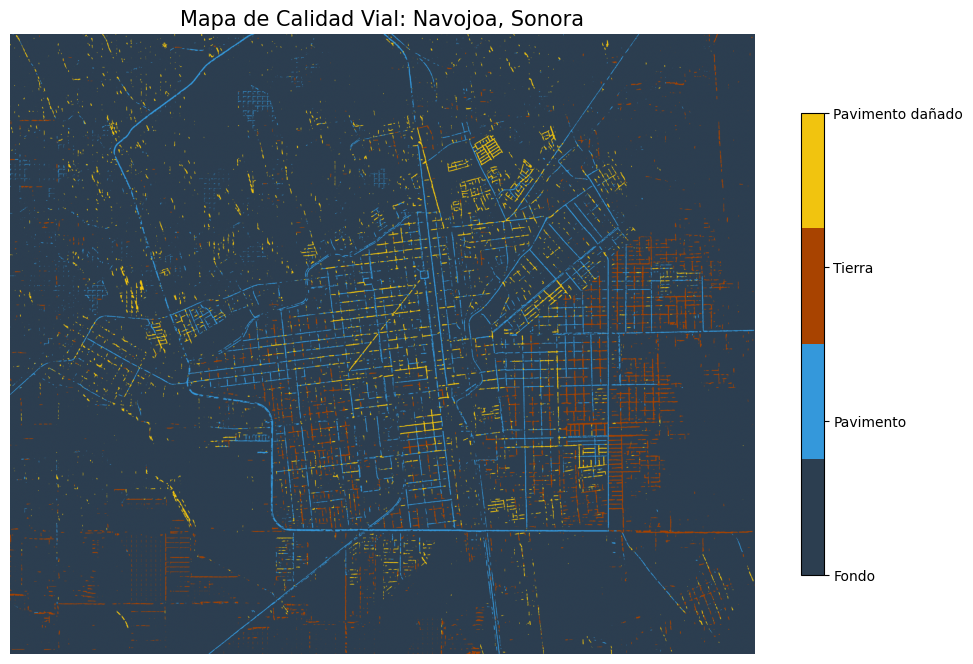

In [12]:
#VISUALIZACIÓN DE LA PREDICCIÓN DEL MODELO
# 0: Otro (Gris)
# 1: Pavimento (Azul)
# 2: Tierra (Café ROJIZO)
# 3: Dañada (AMARILLO)
colores_alerta = ['#2c3e50', "#3498db", '#a84300', '#f1c40f'] # F1C40F es el amarillo institucional
mi_cmap_alerta = ListedColormap(colores_alerta)

with rasterio.open('mapa_prediccion_navojoa.tif') as src:
    preview = src.read(1, out_shape=(src.height // 10, src.width // 10))

plt.figure(figsize=(12, 10))
plt.imshow(preview, cmap=mi_cmap_alerta)
cbar = plt.colorbar(ticks=[0, 1, 2, 3], shrink=0.6)
cbar.ax.set_yticklabels(['Fondo', 'Pavimento', 'Tierra', 'Pavimento dañado'])
plt.title("Mapa de Calidad Vial: Navojoa, Sonora", fontsize=15)
plt.axis('off')
plt.show()


In [13]:

##calculo de procentajes
with rasterio.open('mapa_prediccion_navojoa.tif') as src:
    data = src.read(1)
    
    # Contar píxeles por clase
    total_pixeles_calle = np.sum(data > 0) # Todo lo que no es fondo
    pavimento_ok = np.sum(data == 1)
    tierra = np.sum(data == 2)
    dañada = np.sum(data == 3)

# Calcular porcentajes sobre el total de calles detectadas
print("--- ESTADÍSTICAS DE INFRAESTRUCTURA: NAVOJOA ---")
print(f"Pavimento en Buen Estado: {(pavimento_ok/total_pixeles_calle)*100:.2f}%")
print(f"Calles de Tierra: {(tierra/total_pixeles_calle)*100:.2f}%")
print(f"¡ALERTA! Calles Dañadas: {(dañada/total_pixeles_calle)*100:.2f}%")

--- ESTADÍSTICAS DE INFRAESTRUCTURA: NAVOJOA ---
Pavimento en Buen Estado: 38.83%
Calles de Tierra: 33.28%
¡ALERTA! Calles Dañadas: 27.89%


In [14]:
#calculo de km

with rasterio.open('mapa_prediccion_navojoa.tif') as src:
    # Obtener la resolución del TIF (metros por píxel)
    res_x, res_y = src.res 
    pixel_area = res_x * res_y # Área de un píxel en m²
    
    data = src.read(1)
    
    # Definir un ancho de calle promedio para Navojoa (aprox 10-12 metros)
    # Esto es necesario para pasar de Superficie (m²) a Longitud (km)
    ancho_calle_m = 10 

    def pixeles_a_km(num_pixeles):
        area_m2 = num_pixeles * pixel_area
        longitud_m = area_m2 / ancho_calle_m
        return longitud_m / 1000 # Convertir a kilómetros

    # Conteos
    pavimento_km = pixeles_a_km(np.sum(data == 1))
    tierra_km = pixeles_a_km(np.sum(data == 2))
    dañada_km = pixeles_a_km(np.sum(data == 3))
    total_km = pavimento_km + tierra_km + dañada_km

print(f"--- REPORTE DE INFRAESTRUCTURA (KILÓMETROS) ---")
print(f"Resolución detectada: {res_x:.2f}m por píxel")
print(f"----------------------------------------------")
print(f"Pavimento en Buen Estado: {pavimento_km:.2f} km")
print(f"Calles de Tierra:         {tierra_km:.2f} km")
print(f"¡ALERTA! Calles Dañadas:  {dañada_km:.2f} km")
print(f"----------------------------------------------")
print(f"Total red vial mapeada:   {total_km:.2f} km")

--- REPORTE DE INFRAESTRUCTURA (KILÓMETROS) ---
Resolución detectada: 0.30m por píxel
----------------------------------------------
Pavimento en Buen Estado: 258.43 km
Calles de Tierra:         221.44 km
¡ALERTA! Calles Dañadas:  185.60 km
----------------------------------------------
Total red vial mapeada:   665.46 km


In [ ]:
##codigo para guardar el mapa en una capa de geopackage
# Carga del mapa de predicción
with rasterio.open('mapa_prediccion_navojoa.tif') as src:
    image = src.read(1)
    transform = src.transform
    crs = src.crs

# Vectorización, es decir, se convierten grupos de píxeles en polígonos
results = (
    {'properties': {'class_id': int(v)}, 'geometry': shape(s)}
    for i, (s, v) in enumerate(
        features.shapes(image, mask=(image > 0), transform=transform)
    )
)

# se crear el GeoDataFrame
gdf_navojoa = gpd.GeoDataFrame.from_features(list(results), crs=crs)

# se guarda como GeoPackage
output_gpkg = "prediccion_navojoa_vector.gpkg"
gdf_navojoa.to_file(output_gpkg, layer='predicciones', driver="GPKG")
